# Installazione requirements

**Installazione pacchetti**


In [ ]:
!pip install umap-learn
!pip install -U sentence-transformers
!pip install ftfy
!pip install -U scikit-learn
!pip install --user -U nltk

     |████████████████████████████████| 86 kB 3.9 MB/s 
     |████████████████████████████████| 1.1 MB 27.7 MB/s 
  Created wheel for umap-learn: filename=umap_learn-0.5.2-py3-none-any.whl size=82709 sha256=45c7da3876ce17e29c5513e94e9f940fb1eca43ee8744e097e536c5bc8db2d9c
  Stored in directory: /root/.cache/pip/wheels/84/1b/c6/aaf68a748122632967cef4dffef68224eb16798b6793257d82
  Created wheel for pynndescent: filename=pynndescent-0.5.5-py3-none-any.whl size=52603 sha256=19f26b4facab5f951c8b45f7881d708e0d7206ccacc0151101a18635adc0d2f3
  Stored in directory: /root/.cache/pip/wheels/af/e9/33/04db1436df0757c42fda8ea6796d7a8586e23c85fac355f476
Successfully built umap-learn pynndescent
     |████████████████████████████████| 78 kB 3.6 MB/s 
     |████████████████████████████████| 3.4 MB 35.8 MB/s 
     |████████████████████████████████| 3.3 MB 29.3 MB/s 
     |████████████████████████████████| 1.2 MB 43.5 MB/s 
     |████████████████████████████████| 61 kB 545 kB/s 
     |████████████████████

# **Sentiment Analysis**

##**Caricamento dati**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

dataset = pd.read_csv("/content/drive/MyDrive/Datasets/IMDB.csv")

In [ ]:
dataset

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [3]:
def convert_label(inp):
    return 0 if inp == "negative" else 1
  
dataset["sentiment"] = dataset["sentiment"].apply(lambda x: convert_label(x))

In [ ]:
dataset

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1
...,...,...
49995,I thought this movie did a down right good job...,1
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",0
49997,I am a Catholic taught in parochial elementary...,0
49998,I'm going to have to disagree with the previou...,0


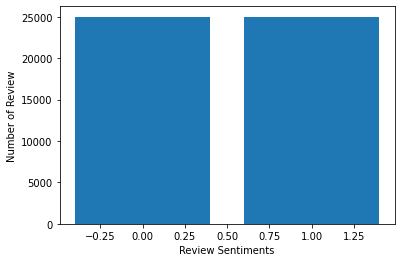

In [ ]:
import matplotlib.pyplot as plt


Sentiment_count=dataset.groupby('sentiment').count()
plt.bar(Sentiment_count.index.values, Sentiment_count['review'])
plt.xlabel('Review Sentiments')
plt.ylabel('Number of Review')
plt.show()

##**Sentiment Analysis con Vader (modello non supervisionato)**

In [ ]:
import nltk
nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [ ]:
from sklearn.metrics import accuracy_score
from nltk.sentiment.vader import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def vader_sentiment_result(sent):
    scores = analyzer.polarity_scores(sent)
    
    if scores["neg"] > scores["pos"]:
        return 0

    return 1
  
dataset["vader_result"] = dataset["review"].apply(lambda x: vader_sentiment_result(x))

vader_accuracy = accuracy_score(dataset["sentiment"], dataset["vader_result"])

In [ ]:
vader_accuracy

0.69224

##**Sentiment Analysis con Multinomial Naive Bayes (modello supervisionato)**

###**Continuous Bag of words**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.tokenize import RegexpTokenizer


token = RegexpTokenizer(r'[a-zA-Z0-9]+')
cv = CountVectorizer(lowercase=True,stop_words='english',ngram_range = (1,1),tokenizer = token.tokenize)
text_counts= cv.fit_transform(dataset['review'])

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    text_counts, dataset['sentiment'], test_size=0.3, random_state=1)

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics


clf = MultinomialNB().fit(X_train, y_train)
predicted= clf.predict(X_test)
print("MultinomialNB Accuracy with CBOW:", metrics.accuracy_score(y_test, predicted))

MultinomialNB Accuracy: 0.8572666666666666


###**Tf-Idf**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.tokenize import RegexpTokenizer
from sklearn.feature_extraction.text import TfidfVectorizer

token = RegexpTokenizer(r'[a-zA-Z0-9]+')
cv = CountVectorizer(lowercase=True,stop_words='english',ngram_range = (1,1),tokenizer = token.tokenize)
text_counts= cv.fit_transform(dataset['review'])

tf=TfidfVectorizer()
text_tf= tf.fit_transform(dataset['review'])

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    text_tf, dataset['sentiment'], test_size=0.3, random_state=123)